<a href="https://colab.research.google.com/github/Prajkta11222/ML_Projects/blob/main/CS23031_prac2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME:-Prajkta Padare USN:CS23031 AIM:-To implement Linear Regression for predicting continuous target variables and evaluate the model performance using appropriate metrics.

Scikit learn -machine learning workflow

a) Train test split & preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:

#import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:


# Step 1: Load the dataset
housing = fetch_california_housing()

# Step 2: Convert features to a DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Step 3: Add the target (median house value) to the DataFrame
# The target represents house values in units of 100,000s
df['target'] = housing.target

# Step 4: Display the first 5 rows
print(df.head())



   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [ ]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        target  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [ ]:
X=df.drop('target',axis=1)
y=df['target']

In [ ]:
X

[       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 14196  3.2596      33.0  5.017657   1.006421      2300.0  3.691814     32.71   
 8267   3.8125      49.0  4.473545   1.041005      1314.0  1.738095     33.77   
 17445  4.1563       4.0  5.645833   0.985119       915.0  2.723214     34.66   
 14265  1.9425      36.0  4.002817   1.033803      1418.0  3.994366     32.69   
 2271   3.5542      43.0  6.268421   1.134211       874.0  2.300000     36.78   
 ...       ...       ...       ...        ...         ...       ...       ...   
 11284  6.3700      35.0  6.129032   0.926267       658.0  3.032258     33.78   
 11964  3.0500      33.0  6.868597   1.269488      1753.0  3.904232     34.02   
 5390   2.9344      36.0  3.986717   1.079696      1756.0  3.332068     34.03   
 860    5.7192      15.0  6.395349   1.067979      1777.0  3.178891     37.58   
 15795  2.5755      52.0  3.402576   1.058776      2619.0  2.108696     37.77   
 
        Longitude  target 

In [ ]:
y

,target
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
X_train.shape

(16512, 8)

In [ ]:
X_test.shape


(4128, 8)

In [ ]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("MODEL EVALUATION METRICS")
print("------------------------")
print("\nMean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R  Score:",r2)

MODEL EVALUATION METRICS
------------------------

Mean Absolute Error: 0.529520818927168
Mean Squared Error: 0.5283876789153481
Root Mean Squared Error: 0.7269027988083057
R  Score: 0.6077292359670401


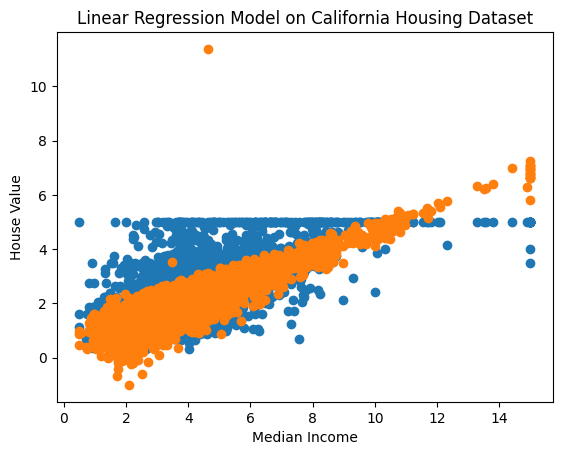

In [ ]:
plt.scatter(X_test['MedInc'],y_test)
plt.scatter(X_test['MedInc'],y_pred)
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Linear Regression Model on California Housing Dataset")
plt.show()